In [91]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
print("Loading processed data...")

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()

print("Shape:", X_train.shape)
print("Fraud ratio:", y_train.mean())

Loading processed data...
Shape: (227845, 30)
Fraud ratio: 0.001729245759178389


In [93]:
# logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc


In [94]:
print("Training Logistic Regression...")

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    log_model, X_train, y_train,
    cv=skf,
    scoring='roc_auc',
    return_train_score=True
)

log_model.fit(X_train, y_train)

log_score = np.mean(cv_results['test_score'])
print("Logistic CV ROC-AUC:", round(log_score, 4))

Training Logistic Regression...
Logistic CV ROC-AUC: 0.9825


In [95]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [96]:
import xgboost as xgb

In [97]:
print("Training XGBoost...")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)

cv_results = cross_validate(
    xgb_model, X_train, y_train,
    cv=skf,
    scoring='roc_auc'
)

xgb_model.fit(X_train, y_train)

xgb_score = np.mean(cv_results['test_score'])
print("XGBoost CV ROC-AUC:", round(xgb_score, 4))

Training XGBoost...
XGBoost CV ROC-AUC: 0.9784


In [98]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [99]:
import lightgbm as lgb

In [100]:
print("Training LightGBM...")

lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42
)

cv_results = cross_validate(
    lgb_model, X_train, y_train,
    cv=skf,
    scoring='roc_auc'
)

lgb_model.fit(X_train, y_train)

lgb_score = np.mean(cv_results['test_score'])
print("LightGBM CV ROC-AUC:", round(lgb_score, 4))

Training LightGBM...
[LightGBM] [Info] Number of positive: 316, number of negative: 181960
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 315, number of negative: 181961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010890 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.00

,Model,ROC-AUC
0,Logistic Regression,0.982495
1,XGBoost,0.978440
2,LightGBM,0.971669


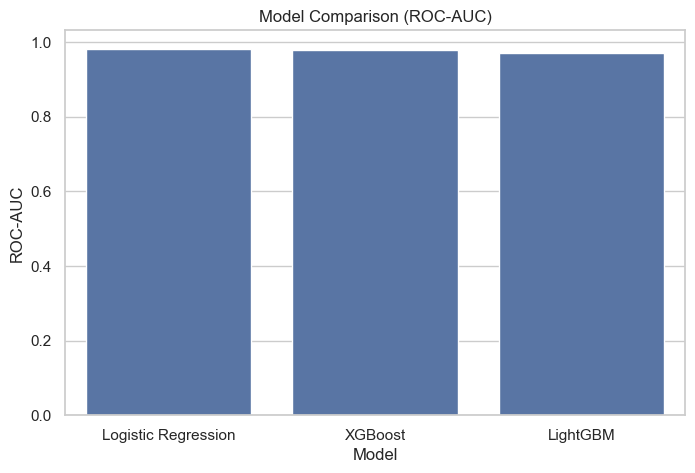

In [101]:
# Model Comparision 
scores = {
    "Logistic Regression": log_score,
    "XGBoost": xgb_score,
    "LightGBM": lgb_score
}

score_df = pd.DataFrame(scores.items(), columns=["Model", "ROC-AUC"])
display(score_df)

sns.barplot(x="Model", y="ROC-AUC", data=score_df)
plt.title("Model Comparison (ROC-AUC)")
plt.show()

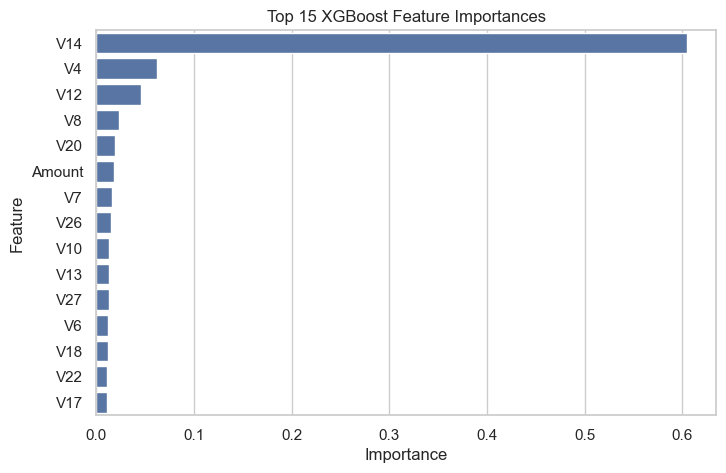

In [102]:
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

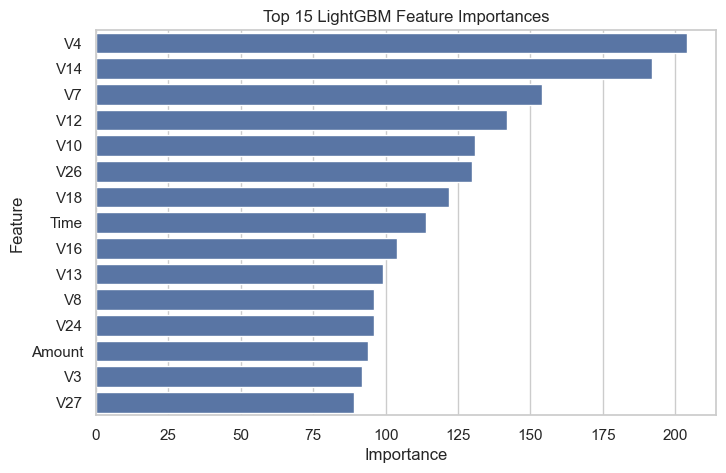

In [103]:
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Top 15 LightGBM Feature Importances")
plt.show()

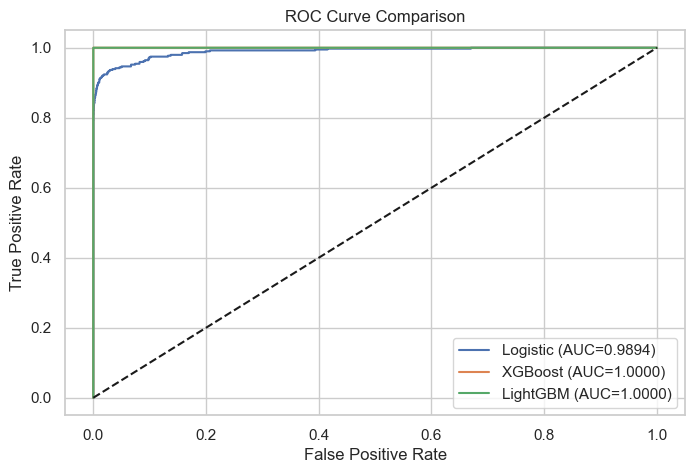

In [104]:
plt.figure()

for model, name in [
    (log_model, "Logistic"),
    (xgb_model, "XGBoost"),
    (lgb_model, "LightGBM")
]:
    y_scores = model.predict_proba(X_train)[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_scores)
    roc_auc = roc_auc_score(y_train, y_scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.4f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

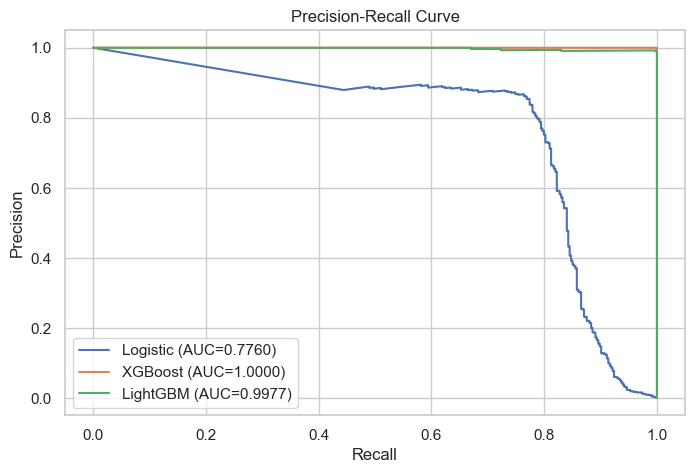

In [105]:
plt.figure()

for model, name in [
    (log_model, "Logistic"),
    (xgb_model, "XGBoost"),
    (lgb_model, "LightGBM")
]:
    y_scores = model.predict_proba(X_train)[:, 1]
    precision, recall, _ = precision_recall_curve(y_train, y_scores)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [106]:
import joblib

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [107]:
best_model_name = max(scores, key=scores.get)
print("Best Model:", best_model_name)

best_model = {
    "Logistic Regression": log_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model
}[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print("Model saved as best_model.pkl")

Best Model: Logistic Regression
Model saved as best_model.pkl


Logistic Regression was selected as the best model with the current CV ROC-AUC scores — this usually means the tree-based models (XGBoost / LightGBM) under-performed compared to what we expect on this dataset.


In [108]:
# ==========================================================
# 📦 IMPORTS
# ==========================================================

import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate

import xgboost as xgb
import lightgbm as lgb

In [109]:
# ==========================================================
# 📁 PATH SETUP
# ==========================================================

BASE_DIR = os.getcwd()  # current notebook folder (src)

MODEL_DIR = os.path.join(BASE_DIR, "models")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "best_model.pkl")

print("Working directory:", BASE_DIR)

Working directory: c:\fraud-detection\src


In [110]:
# ==========================================================
# 📂 LOAD DATA
# ==========================================================

print("📂 Loading data from src folder...")

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
X_test  = pd.read_csv("X_test.csv")
y_test  = pd.read_csv("y_test.csv").values.ravel()

print("✅ Data loaded successfully")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

📂 Loading data from src folder...
✅ Data loaded successfully
Train shape: (227845, 30)
Test shape : (56962, 30)


In [111]:
# ==========================================================
# 🧠 TRAIN + CROSS VALIDATION FUNCTION
# ==========================================================

def train_and_cv(model, X, y, name):
    print(f"\n🚀 Training + CV: {name}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=skf,
        scoring=("roc_auc", "average_precision"),
        n_jobs=-1
    )

    print(f"CV ROC-AUC: {np.mean(cv_results['test_roc_auc']):.5f}")
    print(f"CV PR-AUC : {np.mean(cv_results['test_average_precision']):.5f}")

    model.fit(X, y)
    return model

In [112]:
# ==========================================================
# 📊 EVALUATION FUNCTION
# ==========================================================

def evaluate_on_test(model, X_test, y_test, name):

    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    roc = roc_auc_score(y_test, probs)
    pr  = average_precision_score(y_test, probs)
    cm  = confusion_matrix(y_test, preds)

    print(f"\n📊 {name} Test Results")
    print(f"ROC-AUC: {roc:.5f}")
    print(f"PR-AUC : {pr:.5f}")
    print("Confusion Matrix:\n", cm)

    return roc, pr

In [113]:
# ==========================================================
# 🤖 DEFINE MODELS
# ==========================================================

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        scale_pos_weight=pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        n_jobs=-1
    )
}

In [114]:
# ==========================================================
# 🚀 TRAIN ALL MODELS
# ==========================================================

print("=== Fraud Detection Training Started ===")

results = {}

for name, model in models.items():
    model = train_and_cv(model, X_train, y_train, name)
    roc, pr = evaluate_on_test(model, X_test, y_test, name)
    results[name] = {"model": model, "pr": pr}

=== Fraud Detection Training Started ===

🚀 Training + CV: LogisticRegression


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
# ==========================================================
# 🏆 SELECT BEST MODEL
# ==========================================================

best_name = max(results, key=lambda x: results[x]["pr"])
best_model = results[best_name]["model"]

print(f"\n🏆 Best Model: {best_name}")
print(f"Best PR-AUC: {results[best_name]['pr']:.5f}")

joblib.dump(best_model, MODEL_PATH)

print("\n✅ Training Complete. Model Saved.")


🏆 Best Model: XGBoost
Best PR-AUC: 0.88000

✅ Training Complete. Model Saved.
